**OverFitting**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

The Signal: You are creating a "ground truth" using a sine wave ($\sin(2\pi X)$). In nature, many signals (like sound waves or seasonal temperatures) follow this oscillating pattern.

The Noise: Real-world sensors aren't perfect. By adding np.random.randn(30) * 0.1, you are introducing "Gaussian Noise" to simulate measurement errors.

The Sorting: np.sort is done purely for plotting purposes, so the line graph doesn't jump back and forth across the screen.

In [ ]:
# Generate data
np.random.seed(0)
X = np.sort(np.random.rand(30))
y = np.sin(2 * np.pi * X) + np.random.randn(30) * 0.1

The Logic: Just like in your previous labs, Scikit-Learn's models require a 2D array ($N$ rows, $1$ column). np.newaxis transforms a flat list of 30 numbers into a vertical column.

np.random.seed(0) is used to ensure reproducibility. Because computers can't generate truly "random" numbers, they use mathematical algorithms to create "pseudo-random" sequences.

In [ ]:
X = X[:, np.newaxis]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

 testing three distinct mathematical hypotheses:

 Degree 1 (Linear): A straight line ($y = mx + c$).

 Degree 3 (Cubic): A flexible curve that can change direction twice.

 Degree 15 (High-Degree): An extremely complex "wiggly" line that can change direction 14 times.




pipeline = Pipeline([("poly", polynomial_features), ("linear", linear_regression)])
This is a highly efficient way to write code. Instead of manually transforming your $X$ into $X^2, X^3, ... X^{15}$, the Pipeline does it automatically.

Step 1: PolynomialFeatures takes your single input (e.g., $0.5$) and expands it into a row of features (e.g., $[0.5, 0.25, 0.125...]$).

Step 2: LinearRegression then treats these as independent inputs and finds the best weights for them.

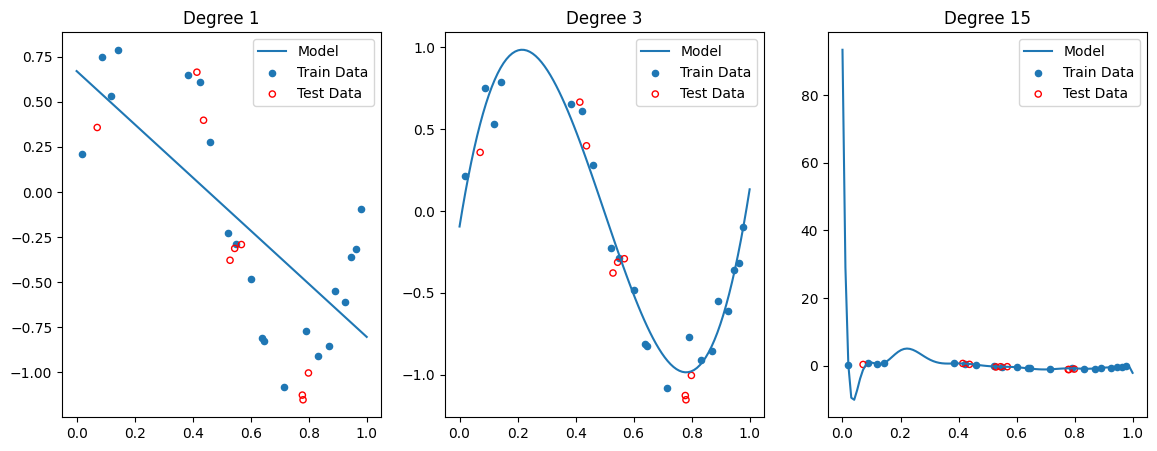

In [ ]:
degrees = [1, 3, 15]

plt.figure(figsize=(14, 5))
for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i + 1)

    # Create a pipeline
    polynomial_features = PolynomialFeatures(degree=degree)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("poly", polynomial_features), ("linear", linear_regression)])

    pipeline.fit(X_train, y_train)

    # Plotting
    X_plot = np.linspace(0, 1, 100)[:, np.newaxis]
    plt.plot(X_plot, pipeline.predict(X_plot), label="Model")
    plt.scatter(X_train, y_train, label="Train Data", s=20)
    plt.scatter(X_test, y_test, label="Test Data", s=20, edgecolors='r', facecolors='none')
    plt.title(f"Degree {degree}")
    plt.legend()

plt.show()

Degree 1: Underfitting (High Bias)
Visual: A flat, straight line cutting through the curve.

Problem: The model is "too biased" toward simplicity. It ignores the obvious curve of the sine wave. It performs poorly on both training and testing data.

Degree 3: The "Sweet Spot" (Ideal)
Visual: A smooth curve that follows the "S" shape of the original sine wave.

Why it works: It captures the true underlying pattern (the signal) without getting distracted by the individual noisy dots. This model will generalize best to your Test Data.

Degree 15: Overfitting (High Variance)
Visual: A wild, zig-zagging line that hits almost every "Train Data" point perfectly but shoots off into infinity between them.

Problem: The model has "memorized" the noise. Look at the Test Data (red circles)—the model's predictions will be massive failures here.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

Ridge(alpha=1.0): This is the "Brake Pedal" for your model. Ridge regression adds a penalty to the loss function based on the square of the magnitude of the coefficients.

If a coefficient ($w$) tries to become too large (which happens during overfitting), the penalty increases.

alpha: This is the tuning parameter. A higher alpha means a stronger penalty, forcing the model to be simpler.


make_pipeline: A shorter, more convenient way to create a Scikit-Learn pipeline without manually naming every step.

In [ ]:
# Model with high complexity (Degree 10) but Ridge penalty (alpha)
model = make_pipeline(PolynomialFeatures(10), Ridge(alpha=1.0))
model.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=10)),
                ('ridge', Ridge())])

Normally, a Degree 10 polynomial would be extremely "wiggly" (overfitting), as we saw in the previous lab with Degree 15.

By adding Ridge, you are telling the model: "You are allowed to be a 10th-degree curve, but I will punish you if you make your weights too large."

The Result: The model will still be a curve, but it will be a smooth, stable curve that ignores the random noise spikes.

Scikit-Learn's regression models, .score() returns the $R^2$ (Coefficient of Determination).1.0: Perfect prediction.0.0: The model is no better than just guessing the average value.

In [ ]:
print(f"Train Score: {model.score(X_train, y_train)}")
print(f"Test Score: {model.score(X_test, y_test)}")

Train Score: 0.6581396260081809
Test Score: 0.5824331805045617


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

A single decision tree is prone to overfitting (it's too "sensitive"). A Random Forest fixes this by building 100 different trees (n_estimators=100) on different subsets of the data.

In [ ]:
model = RandomForestRegressor(n_estimators=100)


 A single train-test split can be "lucky" or "unlucky" depending on which points end up in the test set.

 The Solution (cv=5): The computer splits your entire dataset into 5 equal groups (folds).

 It trains on 4 folds and tests on the 1st.

 It trains on a different 4 folds and tests on the 2nd.T

 This repeats 5 times.

 The Output: scores is an array of 5 $R^2$ values. This gives you a complete picture of how the model performs across the entire dataset.

In [ ]:
scores = cross_val_score(model, X, y, cv=5)

scores.mean(): The average performance.

scores.std() * 2: This represents the 95% Confidence Interval.

In [ ]:

print(f"Mean Accuracy: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Mean Accuracy: -1.09 (+/- 4.03)


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

Sequential Learning: Boosting starts with a weak model and adds trees one by one. Each tree focuses on the "difficult" data points that the previous trees got wrong.

n_estimators=1000: This sets a very high upper limit. You are essentially saying, "I'm willing to build up to 1000 trees, but I hope to stop much earlier."

In [ ]:
# n_iter_no_change: stop if validation score doesn't improve for 5 iterations
model = GradientBoostingRegressor(n_estimators=1000,
                                  validation_fraction=0.1,
                                  n_iter_no_change=5,
                                  tol=0.01)
model.fit(X_train, y_train)



GradientBoostingRegressor(n_estimators=1000, n_iter_no_change=5, tol=0.01)

model.estimators_ is a list of all the trees that were actually built.

Interpretation: Even though you asked for 1000 trees, you will likely see that it stopped at 50, 100, or 200.

In [ ]:
print(f"Stopped at iteration: {len(model.estimators_)}")

Stopped at iteration: 20


**Underfitting**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42): As we discussed, this ensures that the "random" noise and points are identical every time you run the lab, which is essential for your PhD reproducibility.

The Independent Variable ($X$): You are creating 50 points between -3 and 3.

The Ground Truth Equation: You are simulating a physical law where $y$ depends on the square of $x$:$$y = 0.5x^2 + x + 2 + \text{noise}$$

The Noise: np.random.randn(50, 1) adds standard Gaussian noise. This simulates real-world "sensor jitter" or measurement error you would find in an IoMT device.

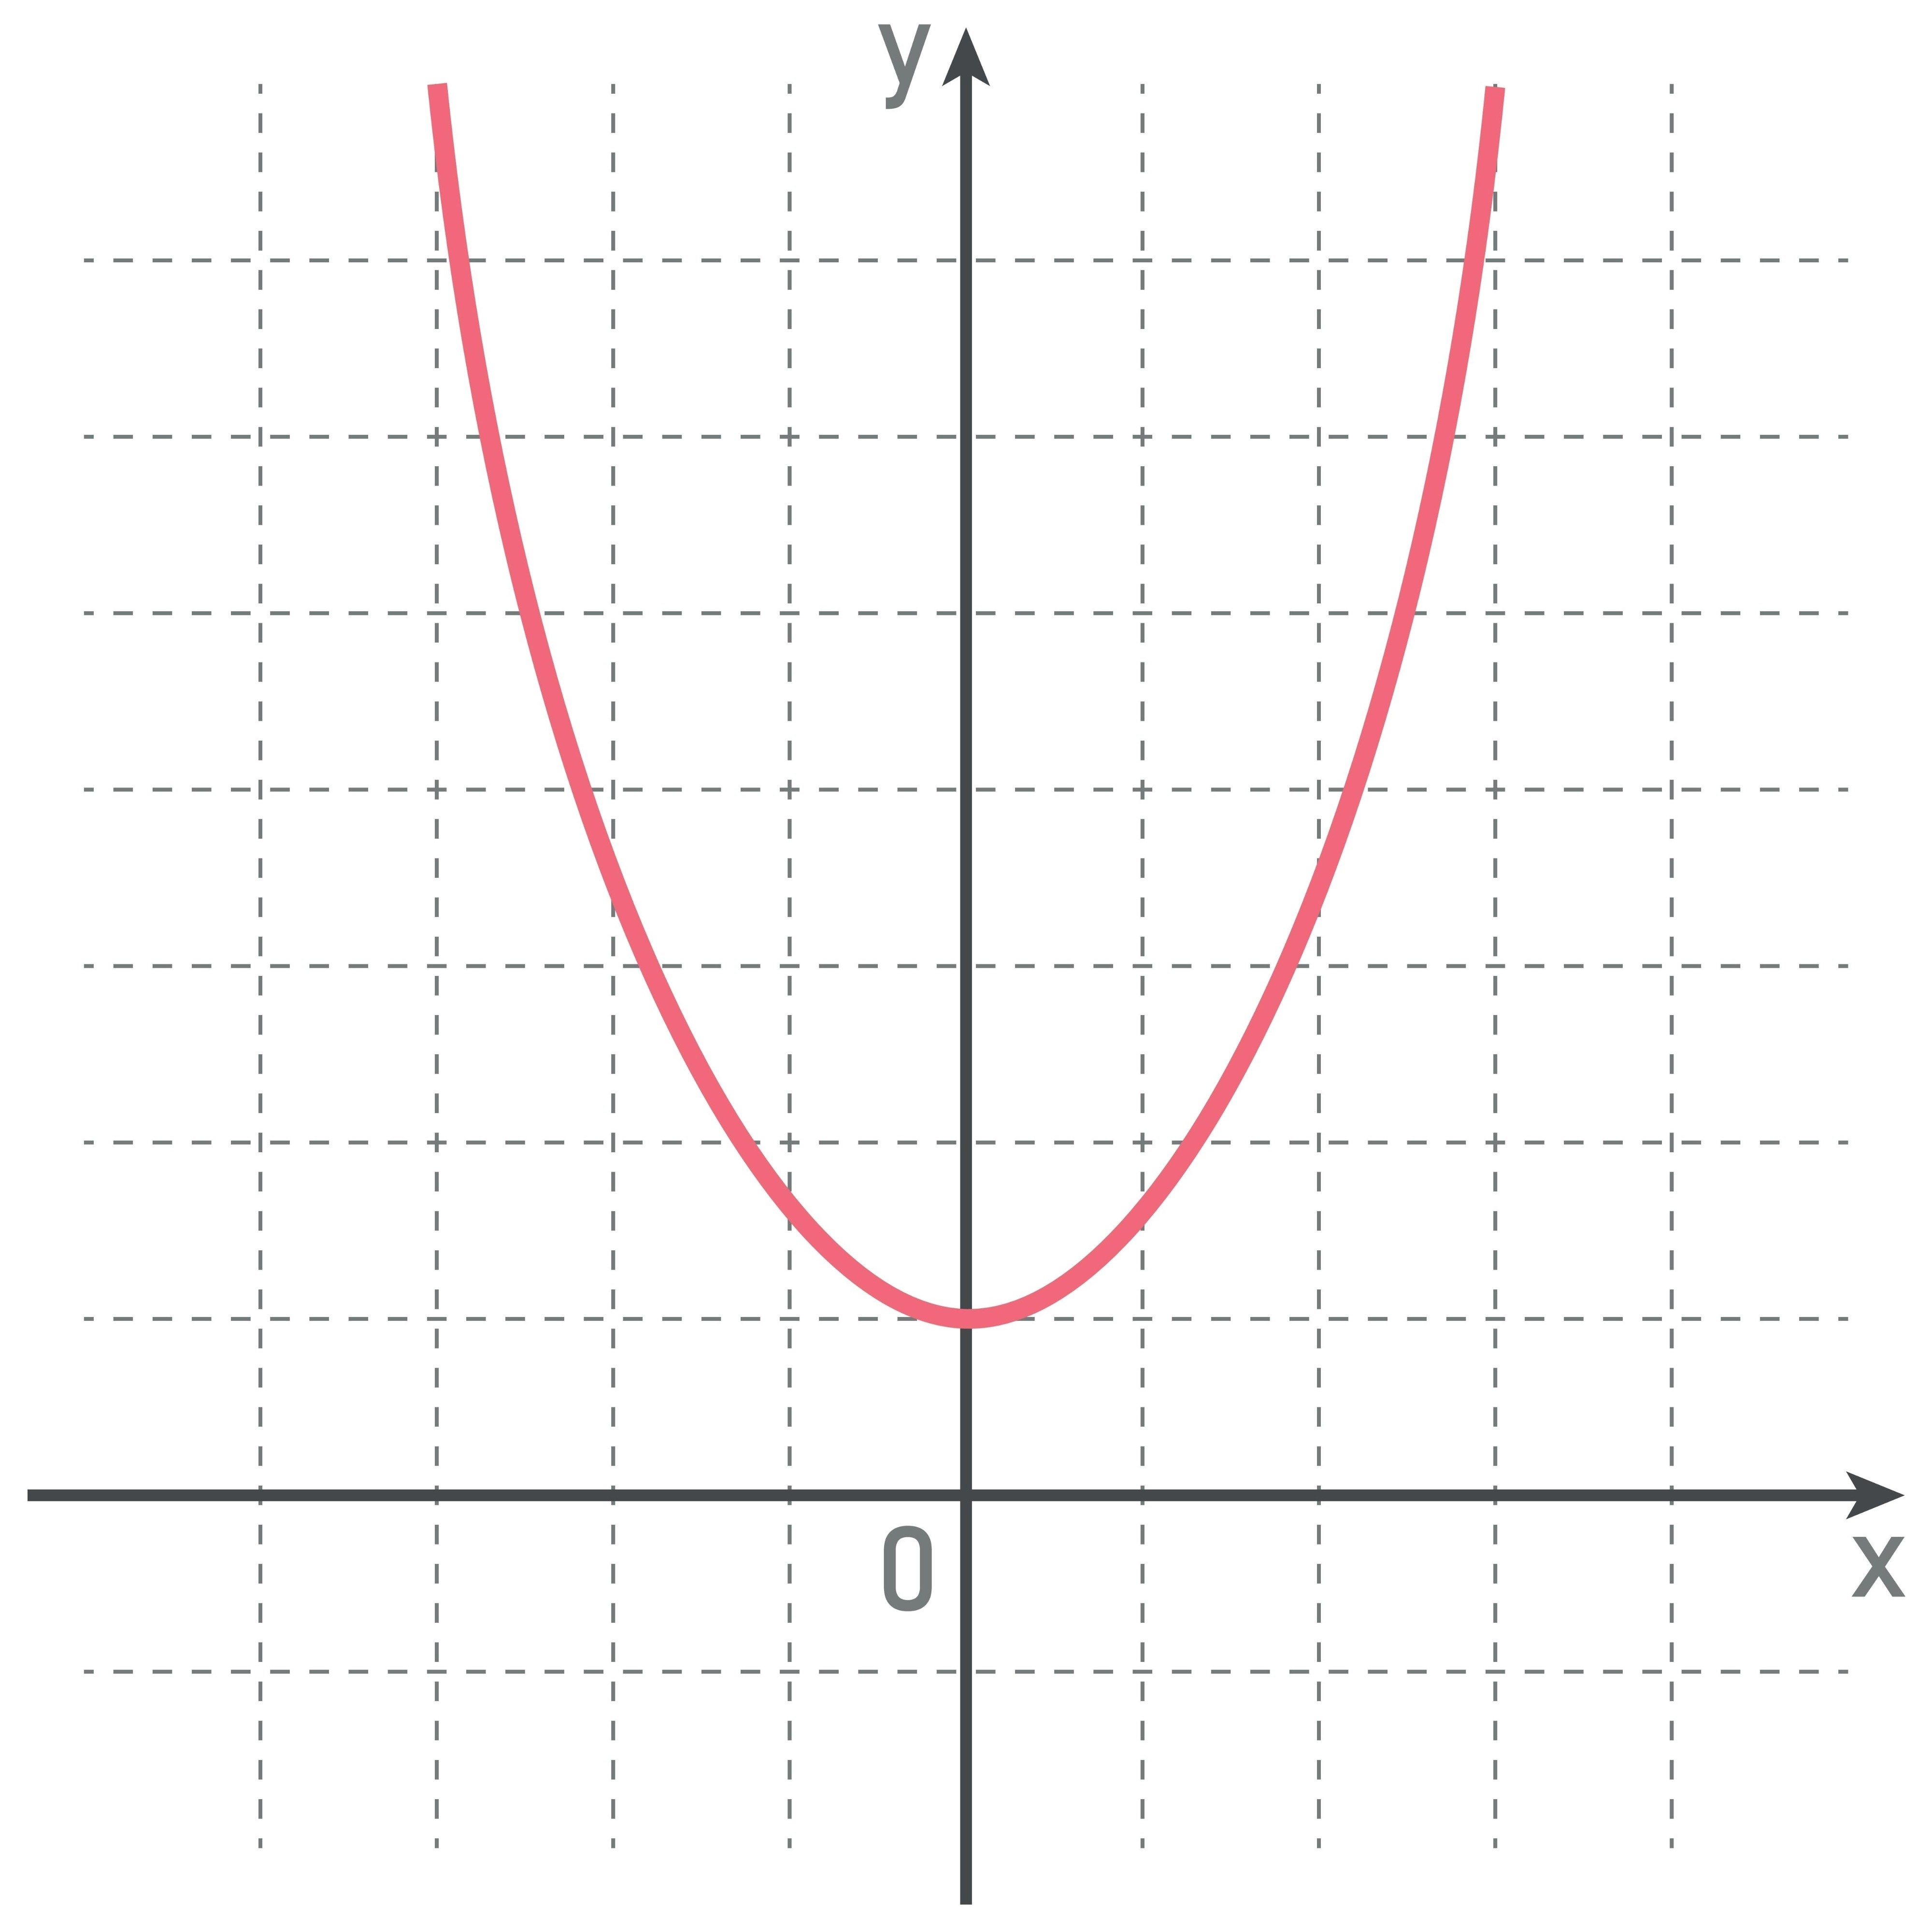

In [ ]:
# Generate non-linear data (Quadratic)
np.random.seed(42)
X = 6 * np.random.rand(50, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(50, 1) # y = 0.5x^2 + x + 2 + noise

Before running any algorithm, a researcher always plots the data.

The Insight: When you see the resulting plot, you'll notice a distinct "U-shape" (a parabola). Because the points don't follow a straight line, your "Linear Intuition" tells you that a simple $y = mx + c$ model will underperform.

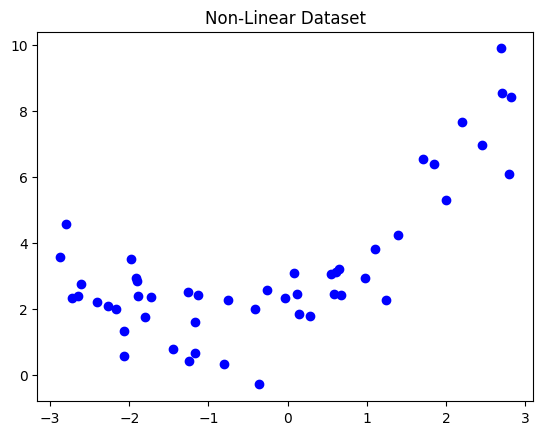

In [ ]:
plt.scatter(X, y, color='blue', label='Data Points')
plt.title("Non-Linear Dataset")
plt.show()

The Conflict: You are trying to fit a straight line ($y = mx + c$) to data that you specifically designed to be quadratic ($y = ax^2 + bx + c$).

The Constraint: The LinearRegression model is mathematically incapable of "bending." It can only find the single straight path that minimizes the total distance to all points.

In [ ]:
# Train a Linear Model
lin_reg = LinearRegression()
lin_reg.fit(X, y)



LinearRegression()

The Visual Result: You will see a stiff, straight red line cutting through a "U-shaped" cluster of blue points.

The "Gap": Notice how the line is consistently above the points in some areas and below them in others (the "ends" and the "middle" of the curve). This systematic error is the hallmark of Underfitting.

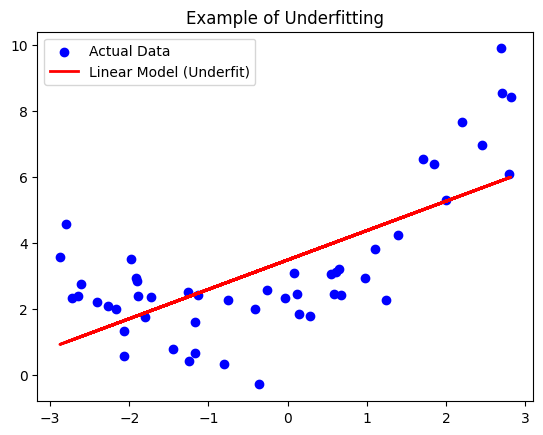

MSE: 2.5711010180410887


In [ ]:
# Predictions
y_pred = lin_reg.predict(X)

# Plotting the Underfit Model
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Linear Model (Underfit)')
plt.legend()
plt.title("Example of Underfitting")
plt.show()

print(f"MSE: {mean_squared_error(y, y_pred)}")

In [ ]:
# Bias and variance tradeoff

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

The Signal: You are using a cosine function: $y = \cos(1.5\pi X)$. This creates a specific "arc" or curve that a simple straight line cannot model accurately.

The Noise: np.random.randn(...) * 0.1 adds Gaussian noise. This is critical for testing Overfitting. Without noise, a high-degree polynomial would be perfectly accurate; with noise, we can see if the model is "hallucinating" patterns in the random errors.

The Sorting: np.sort ensures that when you eventually plot the line, it flows smoothly from left to right instead of jumping around.

In [ ]:
# Generate a noisy cosine wave
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1



.reshape(-1, 1) takes your flat list of 100 numbers and turns it into a vertical column (100 rows, 1 column).

You are using 60% of the data to "train" the model and keeping 40% as a "blind test."

In [ ]:
X = X.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

Testing 12 different mathematical "depths."

The Pipeline: For each iteration, you create a new model that expands the single $X$ feature into $X, X^2, X^3 \dots X^{12}$.

The Goal: You are tracking how the Error (MSE) changes as the model gets more "power" to bend.

Training Error: How well the model "memorizes" the data it was given. This almost always goes down as degree increases.

Testing Error: How well the model "generalizes" to the 40% unseen data. This usually goes down at first, hits a minimum, and then skyrockets.

In [ ]:
degrees = range(1, 13)
train_errors, test_errors = [], []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)

    train_errors.append(mean_squared_error(y_train, model.predict(X_train)))
    test_errors.append(mean_squared_error(y_test, model.predict(X_test)))

plt.yscale('log')

The Log Scale: When a model overfits (like at Degree 12), the error doesn't just double—it can grow by 1,000 or 1,000,000 times. A logarithmic scale allows you to see both the small, healthy errors and the massive overfit errors on the same graph.

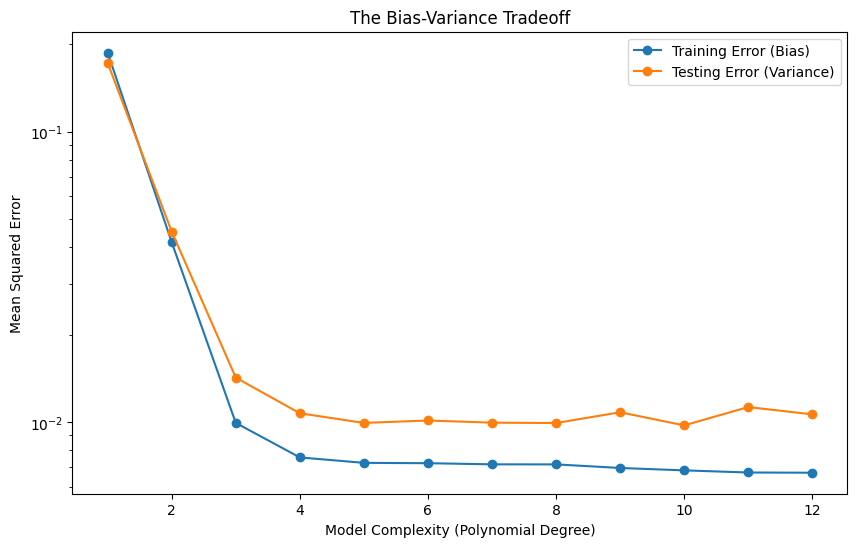

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Training Error (Bias)', marker='o')
plt.plot(degrees, test_errors, label='Testing Error (Variance)', marker='o')
plt.yscale('log') # Use log scale to see the divergence clearly
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error')
plt.title('The Bias-Variance Tradeoff')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

The Ground Truth: You are simulating a Quadratic Relationship ($0.5x^2 + x + 2$).

The Partition: You split the data 70/30. This is the cornerstone of research validation—training on one set and auditing the performance on a separate, "unseen" test set.

In [ ]:
# 1. Setup Data
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1) - 2, axis=0)
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1) * 0.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

 ExperimentThe code iterates through three specific scenarios to show the evolution of a model's "intelligence":
 Degree 1: Underfitting (High Bias)

 The Math: The model tries to fit a straight line ($y = mx + c$) to a curve.

 The Result: High Train MSE and high Test MSE. The model is too "stiff" to understand the data's curvature.

 Degree 2: Optimal Fit (The "Sweet Spot")

 The Math: The model uses $X$ and $X^2$, which perfectly matches the "Ground Truth" equation you used to generate the data.

 The Result: Lowest possible Test MSE. It captures the signal while ignoring most of the random noise.

 Degree 20: Overfitting (High Variance)

 The Math: The model has 20 different "knobs" to turn. It is so powerful that it tries to pass through every single blue (Train) dot, including the random noise.

 The Result: Near-zero Train MSE but a massive, exploding Test MSE. The black line will look wild and zig-zagging.

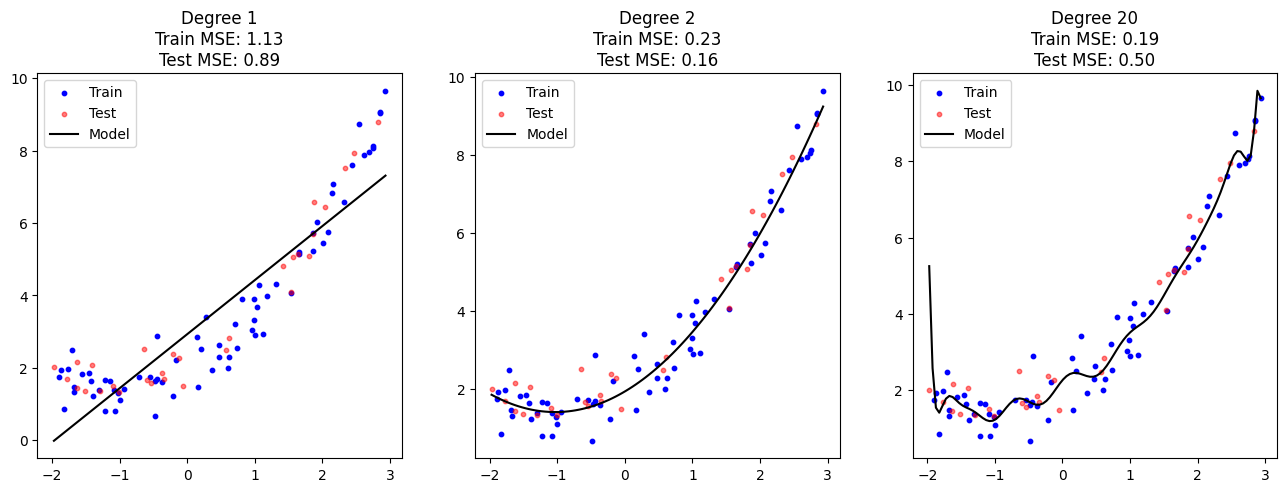

In [ ]:
# 2. Define Degrees to test
degrees = [1, 2, 20]
plt.figure(figsize=(16, 5))

for i, degree in enumerate(degrees):
    # Create and fit model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # 3. Visualization
    ax = plt.subplot(1, 3, i + 1)
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    plt.scatter(X_train, y_train, color='blue', s=10, label="Train")
    plt.scatter(X_test, y_test, color='red', s=10, label="Test", alpha=0.5)
    plt.plot(X_range, model.predict(X_range), color='black', label="Model")

    plt.title(f"Degree {degree}\nTrain MSE: {train_mse:.2f}\nTest MSE: {test_mse:.2f}")
    plt.legend()

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)


Small Gap + High Error: are Underfitting.

Large Gap (Train low, Test high): are Overfitting.

Small Gap + Low Error: have achieved a Generalizable Model.

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

CV Cross Validation
In regression, we use CV to find the average Mean Squared Error (MSE) or $R^2$ across different subsets of data

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

In [ ]:
# 1. Load Data
data = fetch_california_housing()
X, y = data.data, data.target

Dividing your entire dataset into 5 equal-sized portions (called folds).

The Process: The model will run 5 separate times. In each iteration, it uses 4 folds for training and the remaining 1 fold for testing. By the end, every single data point has been used for testing exactly once.

In [ ]:
# 2. Define the Model and CV Strategy
model_lin = LinearRegression()
# KFold with shuffle ensures data isn't ordered (e.g., by zip code)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(model_lin, X, y, cv=kf, scoring='r2')
This is the "engine" of the validation. It combines your model, your data, and your cross-validation strategy (kf) into one operation.

model_lin: The specific algorithm you are testing (e.g., Linear Regression).

cv=kf: This tells the function to use the 5-fold split you defined earlier. It will train and test the model 5 separate times.

scoring='r2': This specifies the metric. $R^2$ (R-squared) measures how much of the variance in your data is explained by the model.

A score of 1.0 is a perfect fit, while 0.0 means the model is no better than a horizontal line.


$Mean \pm SD$.

np.mean(cv_r2): This represents the "expected" performance of your model on new data. It is a much more honest metric than a single test score.

np.std(cv_r2): This measures Model Risk. A low standard deviation means the model is "reliable"—it performs the same way regardless of which data points it sees. In IoMT (Medical Things), high reliability is often more important than high peak accuracy.

In [ ]:
# 3. Perform Cross-Validation (Scoring R-squared)
cv_r2 = cross_val_score(model_lin, X, y, cv=kf, scoring='r2')

print("--- Linear Regression CV Results ---")
print(f"R2 Scores per Fold: {cv_r2}")
print(f"Average R2: {np.mean(cv_r2):.4f}")
print(f"Standard Deviation: {np.std(cv_r2):.4f}")

--- Linear Regression CV Results ---
R2 Scores per Fold: [0.57578771 0.61374822 0.60856043 0.62126494 0.5875292 ]
Average R2: 0.6014
Standard Deviation: 0.0170


**Stratified K-Fold**

For classification, we use Stratified K-Fold. This ensures each fold has the same percentage of each class (e.g., if 10% of your data is "Cancer", every fold will have exactly 10% "Cancer").

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold


In [ ]:
# 1. Load Data
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

Logistic Regression is the baseline for binary classification. It predicts the probability of a class (e.g., $0$ for Benign, $1$ for Malignant).

max_iter=10000: This is a "safety" setting. Iterative solvers need time to find the optimal weights (convergence). In complex or scaled datasets, the default ($100$) often isn't enough, causing the model to throw a "Failed to Converge" warning.

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
This is a more advanced version of the standard KFold you used previously.

The Problem (Class Imbalance): Imagine a dataset where $90\%$ of patients are healthy and $10\%$ have a rare disease. In a regular KFold, one of your folds might accidentally contain zero sick patients, making it impossible for the model to test its detection capability on that fold.

The Solution (Stratification): Stratified K-Fold looks at the target labels and ensures that every fold has the same percentage of each class as the original dataset. If your data is $30\%$ malignant, every single one of your 5 folds will be exactly $30\%$ malignant.


In [ ]:
# 2. Define Model and Stratified CV
model_log = LogisticRegression(max_iter=10000)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# 3. Perform CV (Scoring Accuracy)
cv_acc = cross_val_score(model_log, X_c, y_c, cv=skf, scoring='accuracy')

print("\n--- Logistic Regression CV Results ---")
print(f"Accuracy per Fold: {cv_acc}")
print(f"Average Accuracy: {np.mean(cv_acc):.4f}")
print(f"Standard Deviation: {np.std(cv_acc):.4f}")


--- Logistic Regression CV Results ---
Accuracy per Fold: [0.96491228 0.92105263 0.96491228 0.94736842 0.97345133]
Average Accuracy: 0.9543
Standard Deviation: 0.0187
